# Lecture 1: Sample Space, Probability Axioms, Conditional Probability

Jamie Haddock

[![Open In
Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jamiehadd/Math-151-Probability/blob/main//Users/jamiehaddock/Documents/GitHub/Math-151-Probability/Lecture1/Lecture1.out.ipynb)

# Sample space and events

Today we start building the formal language of probability: what we are
allowed to ask probabilities *of*, and what rules those probabilities
must satisfy.

## Random experiments and sample spaces

> **Exercise: What do these have in common?**
>
> Flipping a coin. Rolling a die. The number of emails that hit your
> inbox tomorrow. Whether a user clicks an ad. What is common to all of
> these situations?

Answer:

Each is a **random experiment**: a procedure whose outcome cannot be
predicted with certainty in advance, but whose set of *possible*
outcomes we can describe completely.

> **Definition: Sample space**
>
> The **sample space** $\Omega$ of a random experiment is the set of all
> possible outcomes of the experiment.

**Examples:**

-   Coin flip: $\Omega = \{H, T\}$
-   Single die roll: $\Omega = \{1,2,3,4,5,6\}$
-   Two die rolls: $\Omega = \{(i,j) : i,j \in \{1,\ldots,6\}\}$, so
    $|\Omega|=36$
-   Time until a server fails: $\Omega = [0,\infty)$

## Events

> **Definition: Event**
>
> An **event** is a subset $A \subseteq \Omega$. We say event $A$
> **occurs** if the outcome of the experiment is an element of $A$.

For the two-dice experiment, some events are:

-   $A = \{(i,j) : i = j\}$ — “doubles”
-   $B = \{(i,j) : i + j \ge 8\}$ — “the sum is at least 8”
-   $\Omega$ itself — the *certain* event
-   $\emptyset$ — the *impossible* event

Because events are just sets, everything you know about set operations
carries over directly: $A \cup B$ (“$A$ or $B$”), $A \cap B$ (“$A$ and
$B$”), and $A^c = \Omega \setminus A$ (“not $A$”).

In [10]:
# The sample space of two fair dice, and two example events, in Python
outcomes = [(i, j) for i in range(1, 7) for j in range(1, 7)]

def A(o):          # event A: doubles
    return o[0] == o[1]

def B(o):           # event B: sum is at least 8
    return (o[0] + o[1]) >= 8

print(f"|Omega| = {len(outcomes)}")
print(f"|A| = {sum(A(o) for o in outcomes)}")
print(f"|B| = {sum(B(o) for o in outcomes)}")

|Omega| = 36
|A| = 6
|B| = 15

------------------------------------------------------------------------

A picture is worth a thousand words: here is $A$ and $B$ drawn as
subsets of a generic sample space $\Omega$.

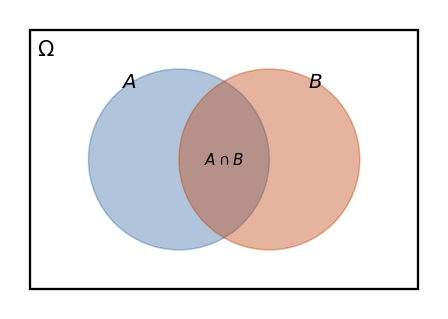

# Probability axioms

We now assign numbers to events. Not just any assignment will do — it
has to obey three simple rules.

## Kolmogorov’s axioms

> **Definition: Probability**
>
> A **probability function** $P$ assigns to every event
> $A \subseteq \Omega$ a number $P(A)$ satisfying:
>
> 1.  $P(A) \ge 0$ for every event $A$.
> 2.  $P(\Omega) = 1$.
> 3.  **Countable additivity:** if $A_1, A_2, \ldots$ are pairwise
>     disjoint events (i.e. $A_i \cap A_j = \emptyset$ for $i \ne j$),
>     then
>     $$P\Big(\bigcup_{i=1}^{\infty} A_i\Big) = \sum_{i=1}^{\infty} P(A_i).$$

That’s it. Everything else we will ever say about probability is a
*consequence* of these three rules.

## Immediate consequences

> **Theorem: Basic properties**
>
> Let $P$ be a probability function on $\Omega$. Then:
>
> 1.  $P(\emptyset) = 0$.
> 2.  $P(A^c) = 1 - P(A)$.
> 3.  If $A \subseteq B$, then $P(A) \le P(B)$ (**monotonicity**).
> 4.  $P(A \cup B) = P(A) + P(B) - P(A \cap B)$ for *any* events $A, B$
>     (not just disjoint ones).

> **Exercise: Prove property 1**
>
> Use axioms 2 and 3 (with $A_1 = \Omega$,
> $A_2 = A_3 = \cdots = \emptyset$) to show $P(\emptyset) = 0$.

Answer:

$\Omega, \emptyset, \emptyset, \ldots$ are pairwise disjoint and their
union is $\Omega$. By countable additivity,
$$P(\Omega) = P(\Omega) + P(\emptyset) + P(\emptyset) + \cdots.$$ Since
$P(\Omega) = 1$ is finite, this forces $P(\emptyset) = 0$.

------------------------------------------------------------------------

Property 4 generalizes to three events as **inclusion–exclusion**:

$$P(A\cup B\cup C) = P(A)+P(B)+P(C) - P(A\cap B) - P(A\cap C) - P(B\cap C) + P(A\cap B\cap C),$$

and a very useful *inequality* version holds for any number of events
(not necessarily disjoint):

> **Theorem: Union bound (Boole’s inequality)**
>
> For any events $A_1, A_2, \ldots$,
> $$P\Big(\bigcup_i A_i\Big) \le \sum_i P(A_i).$$

We will reuse the union bound constantly once we start bounding the
probability of *rare* events later in the course.

## From axioms to intuition: relative frequency

The axioms are abstract on purpose — they don’t say *how* to compute
$P(A)$ for a real experiment. But they are exactly the rules obeyed by
long-run relative frequencies. Let’s check that empirically.

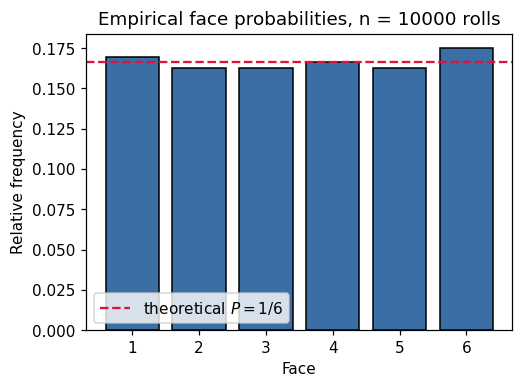

Sum of empirical probabilities: 1.0  (should be 1, matching axiom 2)

In [12]:
# Roll a fair die many times and track the relative frequency of each face
n = 10_000
rolls = rng.integers(1, 7, size=n)
faces, counts = np.unique(rolls, return_counts=True)
emp_probs = counts / n

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(faces, emp_probs, color="#3a6ea5", edgecolor="black")
ax.axhline(1 / 6, color="crimson", linestyle="--", label="theoretical $P=1/6$")
ax.set_xlabel("Face")
ax.set_ylabel("Relative frequency")
ax.set_title(f"Empirical face probabilities, n = {n} rolls")
ax.legend()
plt.show()

print("Sum of empirical probabilities:", emp_probs.sum(), " (should be 1, matching axiom 2)")

------------------------------------------------------------------------

Try changing `n` in the cell above. As $n$ grows, the bars should hug
the dashed line more and more tightly — this is the **Law of Large
Numbers**, which we will make precise later in the course. For now, just
notice that the axioms (nonnegativity, total probability 1) hold
*exactly* for every $n$, no matter how the frequencies wiggle around.

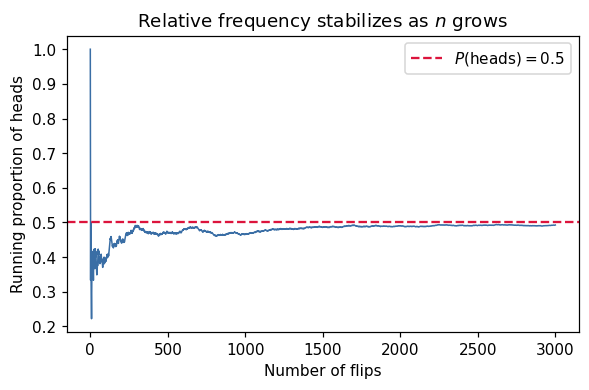

In [13]:
# The running proportion of heads in a sequence of fair coin flips
n_max = 3000
flips = rng.integers(0, 2, size=n_max)          # 0 = tails, 1 = heads
running_freq = np.cumsum(flips) / np.arange(1, n_max + 1)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(running_freq, color="#3a6ea5", linewidth=1)
ax.axhline(0.5, color="crimson", linestyle="--", label="$P(\\text{heads}) = 0.5$")
ax.set_xlabel("Number of flips")
ax.set_ylabel("Running proportion of heads")
ax.set_title("Relative frequency stabilizes as $n$ grows")
ax.legend()
plt.show()

# Conditional probability

What happens to our probabilities once we learn some partial information
about the outcome?

## Definition and intuition

> **Exercise: A card is drawn**
>
> A single card is drawn from a standard 52-card deck. You are told the
> card is a face card (J, Q, or K). Given this information, what is the
> probability that it’s a King?

Answer:

There are 12 face cards, 4 of which are Kings, so intuitively the answer
is $4/12 = 1/3$. Notice what happened: we **restricted the sample
space** from all 52 cards down to the 12 face cards, then asked what
fraction of that smaller space is Kings.

> **Definition: Conditional probability**
>
> For events $A$ and $B$ with $P(B) > 0$, the **conditional probability
> of $A$ given $B$** is $$P(A \mid B) = \frac{P(A \cap B)}{P(B)}.$$

Read $P(A\mid B)$ as: “having learned that $B$ occurred, what fraction
of $B$’s probability is also in $A$?” This is exactly the
restrict-the-sample-space intuition from the card example.

------------------------------------------------------------------------

> **Theorem: Conditional probability is a probability**
>
> For fixed $B$ with $P(B)>0$, the function $A \mapsto P(A\mid B)$
> satisfies all three of Kolmogorov’s axioms on the reduced sample space
> $B$.

This is a useful sanity check: whatever theorem you prove about
probabilities in general, you’re automatically allowed to apply it to
conditional probabilities too — just condition everything on $B$
throughout.

## Visualizing conditioning with two dice

Let’s go back to our two-dice example: $A$ = doubles, $B$ = sum is at
least 8. We’ll compute $P(A \mid B)$ two ways — exactly, by enumerating
the sample space, and empirically, by simulation.

In [14]:
# Exact computation by enumerating the 36 equally likely outcomes
N = len(outcomes)
P_A = sum(A(o) for o in outcomes) / N
P_B = sum(B(o) for o in outcomes) / N
P_AB = sum(A(o) and B(o) for o in outcomes) / N
P_A_given_B = P_AB / P_B

print(f"P(A)        = {P_A:.4f}   (A = doubles)")
print(f"P(B)        = {P_B:.4f}   (B = sum >= 8)")
print(f"P(A and B)  = {P_AB:.4f}")
print(f"P(A | B)    = {P_A_given_B:.4f}")

P(A)        = 0.1667   (A = doubles)
P(B)        = 0.4167   (B = sum >= 8)
P(A and B)  = 0.0833
P(A | B)    = 0.2000

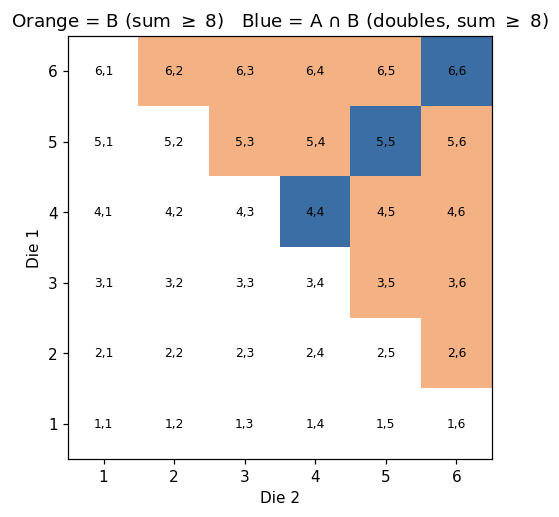

------------------------------------------------------------------------

$P(A\mid B)$ is just the fraction of the **orange region** (all 15 cells
where $B$ happens) that is also **blue** (where $A$ happens too):
$3/15 = 1/5$. Conditioning literally shrinks the sample space down to
$B$ and asks about $A$ from there.

In [16]:
# Confirm with a Monte Carlo simulation
n = 200_000
d1 = rng.integers(1, 7, size=n)
d2 = rng.integers(1, 7, size=n)

in_B = (d1 + d2) >= 8
in_A_and_B = (d1 == d2) & in_B

emp_P_A_given_B = in_A_and_B.sum() / in_B.sum()
print(f"Simulated P(A | B) over {n:,} rolls: {emp_P_A_given_B:.4f}")
print(f"Exact P(A | B):                    {P_A_given_B:.4f}")

Simulated P(A | B) over 200,000 rolls: 0.2007
Exact P(A | B):                    0.2000

------------------------------------------------------------------------

> **Exercise: Try your own events**
>
> In the cells above, redefine `A` and/or `B` (for example,
> `A = "sum is even"`, or `B = "at least one die shows a 6"`), rerun the
> enumeration and simulation cells, and see whether the exact and
> simulated values still agree. Before rerunning, guess whether
> $P(A\mid B)$ should be bigger, smaller, or the same as $P(A)$.

## Summary and looking ahead

-   A **sample space** $\Omega$ collects all possible outcomes; an
    **event** is a subset of $\Omega$.
-   A **probability function** $P$ must satisfy nonnegativity,
    $P(\Omega)=1$, and countable additivity — everything else
    (complements, monotonicity, inclusion–exclusion, the union bound)
    follows from these three rules.
-   **Conditional probability** $P(A\mid B) = P(A\cap B)/P(B)$
    formalizes “restricting the sample space” after learning that $B$
    occurred, and is itself a valid probability function.

**Next time:** independence and Bayes’ Law — the tools that will let us
build our first real classifier (a Naive Bayes spam filter) directly
from conditional probability.

*Reading: Harchol-Balter, Ch. 2.4–2.6.*